# 1. Setup

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from scipy.stats import norm as NormDist

# --- plotting style: keep grid/axes recessive so the data dominates -------------
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention, continued from Notebook 2:
#   simulation total = black, common-envelope channel = orange, stable-mass-transfer = teal,
#   observations (LVK) = purple, "the wrong way of doing it" = grey
CSYS, C_CE, C_SMT, C_OBS, C_WRONG = "#222222", "#E07B39", "#2A9D8F", "#7B2CBF", "#999999"

# >>> CHANGE THIS LINE to wherever you unpacked the Notebook 2 data file <<<
DATA_PATH = "../../../data/COMPAS_Output_wWeights.h5"

Z_SUN = 0.0142          # solar metallicity used by the authors (Asplund et al. 2009)
BH, NS = 14, 13         # Hurley et al. (2000) stellar type codes

print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__,
      "| cosmology:", cosmo.name, f"(H0 = {cosmo.H0.value:.1f}, Om0 = {cosmo.Om0:.3f})")

numpy 2.5.1 | h5py 3.16.0 | pandas 3.0.5 | cosmology: Planck18 (H0 = 67.7, Om0 = 0.310)


In [9]:
DCO_COLUMNS = ["SEED", "Mass(1)", "Mass(2)", "Stellar_Type(1)", "Stellar_Type(2)",
               "Merges_Hubble_Time", "Coalescence_Time", "Time", "Metallicity@ZAMS(1)",
               "CE_Event_Counter", "mixture_weight"]

with h5py.File(DATA_PATH, "r") as f:
    dco = pd.DataFrame({c: f["BSE_Double_Compact_Objects"][c][()] for c in DCO_COLUMNS})

    Z_all_systems = f["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]


n_binaries_simulated = len(Z_all_systems)

dco = dco.rename(columns={
    "Mass(1)": "M1_raw", "Mass(2)": "M2_raw", "Stellar_Type(1)": "type1", "Stellar_Type(2)": "type2",
    "Metallicity@ZAMS(1)": "Z", "Merges_Hubble_Time": "merges", "Coalescence_Time": "t_coal_Myr",
    "Time": "t_form_Myr", "CE_Event_Counter": "n_CE", "mixture_weight": "w",
})
dco["is_BBH"]  = (dco.type1 == BH) & (dco.type2 == BH)
dco["is_BHNS"] = (dco.type1 == BH) ^ (dco.type2 == BH)
dco["is_BNS"]  = (dco.type1 == NS) & (dco.type2 == NS)
dco["m1"] = np.maximum(dco.M1_raw, dco.M2_raw)
dco["m2"] = np.minimum(dco.M1_raw, dco.M2_raw)
dco["t_delay_Myr"] = dco.t_form_Myr + dco.t_coal_Myr


In [89]:
# --- Kroupa (2001) IMF: a three-part broken power law, dN/dm ∝ m^-alpha ----------------
IMF_BOUNDS = (0.01, 0.08, 0.5, 200.0)
IMF_SLOPES = (0.3, 1.3, 2.3)
M1_MIN, M1_MAX, M2_MIN, F_BIN = 5.0, 150.0, 0.1, 0.7


def kroupa_imf(m):
    '''dN/dm (unnormalised), continuous across the breaks.'''
    m = np.asarray(m, dtype=float)
    m0, m1, m2, m3 = IMF_BOUNDS
    a1, a2, a3 = IMF_SLOPES
    c2 = m1 ** (a2 - a1)
    c3 = c2 * m2 ** (a3 - a2)
    out = np.where(m < m1, m ** -a1, np.where(m < m2, c2 * m ** -a2, c3 * m ** -a3))
    return np.where((m >= m0) & (m <= m3), out, 0.0)


# normalise so that the integral of dN/dm over all masses is 1  ->  a probability density
_norm = quad(kroupa_imf, IMF_BOUNDS[0], IMF_BOUNDS[-1], points=IMF_BOUNDS[1:-1])[0]
imf_pdf = lambda m: kroupa_imf(m) / _norm

frac_number = quad(imf_pdf, M1_MIN, M1_MAX)[0]
mass_pdf = lambda m: m * imf_pdf(m)
m_avg = quad(mass_pdf, IMF_BOUNDS[0], IMF_BOUNDS[-1], points=IMF_BOUNDS[1:-1])[0]
frac_mass = quad(mass_pdf, M1_MIN, M1_MAX)[0] / m_avg
print(f"average mass of a star drawn from the IMF          : {m_avg:.3f} Msun")
print(f"fraction of stars (by number) born with 5-150 Msun : {100*frac_number:.2f}%   (1 in {1/frac_number:.0f})")
print(f"fraction of stellar MASS in stars of 5-150 Msun    : {100*frac_mass:.1f}%")

average mass of a star drawn from the IMF          : 0.389 Msun
fraction of stars (by number) born with 5-150 Msun : 0.75%   (1 in 134)
fraction of stellar MASS in stars of 5-150 Msun    : 26.9%


In [102]:
# Mass represented per bin
mass_per_binary_drawn = m_avg * (1.5 + (1 - F_BIN) / F_BIN)
f_sim = quad(lambda m: imf_pdf(m) * (1 - M2_MIN / m), M1_MIN, M1_MAX)[0]

M_REP = mass_per_binary_drawn / f_sim
M_SIM = n_binaries_simulated * M_REP


# Assign each system to it metallicity Bin
N_Z_BINS = 50
LOG_Z_MIN, LOG_Z_MAX = np.log10(Z_all_systems.min()), np.log10(Z_all_systems.max())
DLOGZ_TOT = LOG_Z_MAX - LOG_Z_MIN
LOG_Z_EDGES = np.linspace(LOG_Z_MIN, LOG_Z_MAX, N_Z_BINS + 1)
def mass_formed_per_bin(log_z_edges):
    '''Star-forming mass represented by the simulation in each log10(Z) bin (flat-in-log sampling).'''
    return M_SIM * np.diff(log_z_edges) / DLOGZ_TOT

# sfr_density
def sfr_density(z, a=0.02, b=1.48, c=4.45, d=5.9):
    '''Madau & Dickinson (2014) functional form; default parameters from van Son et al. (2023).
    Returns Msun / yr / Mpc^3 (comoving).'''
    return a * (1 + z) ** b / (1 + ((1 + z) / c) ** d)

# dP_dlnZ
def dP_dlnZ(lnZ, z, mu0=0.025, muz=-0.05, sigma0=1.125, sigmaz=0.05, alpha=-1.77):
    '''Skewed log-normal metallicity distribution of van Son et al. (2023), section 2.
    Returns dP/dlnZ at natural-log metallicities `lnZ` (1D) for redshifts `z` (1D): shape (len(z), len(lnZ)).
    Normalised so that the integral over lnZ from -inf to +inf is 1 at every redshift.'''
    z = np.atleast_1d(z)[:, None]; lnZ = np.atleast_1d(lnZ)[None, :]
    sigma = sigma0 * 10 ** (sigmaz * z)                         # width grows slowly with z
    mean_Z = mu0 * 10 ** (muz * z)                              # mean metallicity falls with z
    beta = alpha / np.sqrt(1 + alpha**2)
    # location parameter mu such that the distribution has mean <Z> = mean_Z
    mu = np.log(mean_Z / 2 / (np.exp(0.5 * sigma**2) * NormDist.cdf(beta * sigma)))
    x = (lnZ - mu) / sigma
    return 2 / sigma * NormDist.pdf(x) * NormDist.cdf(alpha * x)

# Time Delay
Z_GRID = np.linspace(0, 20, 4001)
T_LB_GRID_MYR = cosmo.lookback_time(Z_GRID).to(u.Myr).value
T_LB_FIRST_STARS_MYR = cosmo.lookback_time(10).to(u.Myr).value     # we start star formation at z = 10


def lookback_time_Myr(z):
    return np.interp(z, Z_GRID, T_LB_GRID_MYR)


def redshift_at_lookback_time(t_lb_Myr):
    '''Inverse of the above. Returns nan for times before z = 20.'''
    return np.interp(t_lb_Myr, T_LB_GRID_MYR, Z_GRID, right=np.nan)

# --- redshift grid for the star formation history ------------------------------------------
Z_SFR_EDGES = np.linspace(0, 10, 201)
z_sfr_centres = 0.5 * (Z_SFR_EDGES[1:] + Z_SFR_EDGES[:-1])
psi_grid = sfr_density(z_sfr_centres) * 1e9 * u.Msun / u.yr / u.Gpc**3          # Mpc^-3 -> Gpc^-3

# --- metallicity grid: the SAME bins as eta (section 1.5), now in linear Z ------------------
Z_EDGES_LIN = 10 ** LOG_Z_EDGES

# fraction of star formation in each metallicity bin, integrated on a fine sub-grid (40 per bin)
N_SUB = 40
lnZ_fine = np.linspace(np.log(Z_EDGES_LIN[0]), np.log(Z_EDGES_LIN[-1]), N_Z_BINS * N_SUB + 1)
P_fine = dP_dlnZ(0.5 * (lnZ_fine[1:] + lnZ_fine[:-1]), z_sfr_centres) * np.diff(lnZ_fine)   # (200, 50*40)
dP_per_bin = P_fine.reshape(len(z_sfr_centres), N_Z_BINS, N_SUB).sum(axis=2)                  # (200, 50)
dPdZ_grid = dP_per_bin / np.diff(Z_EDGES_LIN)[None, :]                                        # what SSPC wants

sfr_dict = {
    "redshift_bin_edges":             Z_SFR_EDGES,
    "starformation_rate_array":       psi_grid,
    "metallicity_bin_edges":          Z_EDGES_LIN,
    "metallicity_distribution_array": dPdZ_grid,
}


In [12]:
import sys, os, copy, logging, time

SSPC_PATH = "/Users/floorbroekgaarden/Projects/GitHub/syntheticstellarpopconvolve"   # only used if the pip install is absent

try:
    import syntheticstellarpopconvolve
except ImportError:
    sys.path.insert(0, SSPC_PATH)
    import syntheticstellarpopconvolve

from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, print_hdf5_structure
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022

print("SSPC version", syntheticstellarpopconvolve.__version__, "imported from", os.path.dirname(syntheticstellarpopconvolve.__file__))

SSPC version 0.4 imported from d:\GROWL\.venv\Lib\site-packages\syntheticstellarpopconvolve


# Exercise 1

As last time, Maryam's codes helped with logic clarification.

In [13]:
# Filter out our data (for BHNS and BNS)
bns = dco[dco.is_BNS & (dco.merges == 1)].copy()
bhns = dco[dco.is_BHNS & (dco.merges == 1)].copy()
bbh = dco[dco.is_BBH & (dco.merges == 1)].copy()

print(f"binaries simulated           : {n_binaries_simulated:,}")
print(f"double compact objects       : {len(dco):,}")
print(f"merging BBH (rows)           : {len(bbh):,}")
print(f"merging BBH (sum w)          : {bbh.w.sum():,.0f}")
print(f"merging BH - NS (rows)       : {len(bhns):,}")
print(f"merging BH - NS (sum w)      : {bhns.w.sum():,.0f}")
print(f"merging BNS (rows)           : {len(bns):,}")
print(f"merging BNS (sum w)          : {bns.w.sum():,.0f}")


binaries simulated           : 10,000,000
double compact objects       : 2,523,122
merging BBH (rows)           : 1,640,550
merging BBH (sum w)          : 14,911
merging BH - NS (rows)       : 192,673
merging BH - NS (sum w)      : 2,918
merging BNS (rows)           : 1,922
merging BNS (sum w)          : 6,508


In [14]:
# Assigning each system to its respective metallicity bin
mass_per_bin = mass_formed_per_bin(LOG_Z_EDGES)
for name, population in [("bbh", bbh), ("bhns", bhns), ("bns", bns)]:
    population["z_bin"] = np.clip(np.digitize(np.log10(population.Z), LOG_Z_EDGES) - 1, 0, N_Z_BINS - 1)
    population["eta"] = population.w / mass_per_bin[population.z_bin.values]


In [15]:
# Fresh SSPC file + input tables + convolution

SSPC_DIR = "data/sspc"
os.makedirs(os.path.join(SSPC_DIR, "tmp"), exist_ok=True)

SSPC_FILE_ORIGINAL = os.path.join(SSPC_DIR, "vanSon22_BBH_cosmic_integration.h5")

## Start from a completely fresh HDF5 file
if os.path.exists(SSPC_FILE_ORIGINAL):
    os.remove(SSPC_FILE_ORIGINAL)

generate_boilerplate_outputfile(SSPC_FILE_ORIGINAL)


# Write all three populations into the fresh SSPC file
for name, population in [("bbh", bbh), ("bhns", bhns), ("bns", bns),]:

    sspc_input = pd.DataFrame({
        "delay_time": population.t_delay_Myr.values,
        "metallicity": population.Z.values,
        "eta": population.eta.values,
    })

    sspc_input.to_hdf(SSPC_FILE_ORIGINAL, key=f"input_data/{name}")
    print(f"{len(sspc_input):,} rows written to input_data/{name}")


# SSPC convolution configuration
CONV_Z_EDGES = np.arange(0.0, 6.41, 0.4)

config = copy.copy(default_convolution_config)

config["logger"].setLevel(logging.ERROR)
config["output_filename"] = SSPC_FILE_ORIGINAL
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator.p")
config["time_type"] = "redshift"
config["cosmology"] = cosmo
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict

config["convolution_instructions"] = [

    ## BBH
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bbh",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },

    ## BHNS
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bhns",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },

    ## BNS
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bns",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },
]

# Run convolution

t0 = time.time()
convolve(config=config)

print(
    f"\nDone in {time.time() - t0:.0f} s; "
    f"output file is now "
    f"{os.path.getsize(SSPC_FILE_ORIGINAL)/1e6:.0f} MB"
)

1,640,550 rows written to input_data/bbh
192,673 rows written to input_data/bhns
1,922 rows written to input_data/bns

Done in 17 s; output file is now 298 MB


In [16]:
with h5py.File(SSPC_FILE_ORIGINAL, "r") as f:

    bhns_yield = f["output_data/bhns/rates/convolution_results/0.2/yield"][:]
    bns_yield  = f["output_data/bns/rates/convolution_results/0.2/yield"][:]
    bbh_yield  = f["output_data/bbh/rates/convolution_results/0.2/yield"][:]

R_bhns = bhns_yield.sum()
R_bns  = bns_yield.sum()
R_bbh  = bbh_yield.sum()

print(f"BHNS merger rate at z=0.2: {R_bhns:.2f} Gpc^-3 yr^-1")
print(f"BNS  merger rate at z=0.2: {R_bns:.2f} Gpc^-3 yr^-1")

def read_sspc_yield(population_name, z_centre):
    with h5py.File(SSPC_FILE_ORIGINAL, "r") as f:
        key = (f"output_data/{population_name}/rates/convolution_results/{np.round(z_centre, 4)}/yield")
        return f[key][()]

CONV_Z = 0.5 * (CONV_Z_EDGES[1:] + CONV_Z_EDGES[:-1])
R_bhns_sspc = np.array([read_sspc_yield("bhns", z).sum() for z in CONV_Z])
R_bns_sspc = np.array([read_sspc_yield("bns", z).sum() for z in CONV_Z])
R_bbh_sspc = np.array([read_sspc_yield("bbh", z).sum() for z in CONV_Z])
print(f"\n{'z':>5s} {'R_bhns':>15s} {'R_bns':>15s} {'R_bbh':>15s}")
print("-" * 55)

for z, r_bhns, r_bns, r_bbh in zip(CONV_Z, R_bhns_sspc, R_bns_sspc, R_bbh_sspc):
    print(f"{z:5.1f} {r_bhns:15.1f} {r_bns:15.1f} {r_bbh:15.1f}")

BHNS merger rate at z=0.2: 62.32 Gpc^-3 yr^-1
BNS  merger rate at z=0.2: 163.24 Gpc^-3 yr^-1

    z          R_bhns           R_bns           R_bbh
-------------------------------------------------------
  0.2            62.3           163.2            67.5
  0.6            94.0           197.5           104.6
  1.0           110.2           218.2           147.8
  1.4           104.2           245.2           194.1
  1.8            82.6           257.3           237.5
  2.2            58.7           248.6           269.8
  2.6            41.3           215.5           284.5
  3.0            29.9           169.8           279.5
  3.4            22.1           125.3           258.3
  3.8            16.3            89.2           227.6
  4.2            12.0            62.5           194.1
  4.6             8.9            44.1           162.0
  5.0             6.5            31.2           133.7
  5.4             4.8            22.5           109.5
  5.8             3.6            16.5   

**Check with Author's Key**

In [17]:
RATES_GROUP = ("Rates_mu00.025_muz-0.05_alpha-1.77_sigma01.125_sigmaz0.05_a0.02_b1.48_c4.45_d5.9_zBinned")
Z_INDEX_02 = 4       # authors' 0.20 < z < 0.25 bin

# name, DCO mask, our population DataFrame, our SSPC rates
populations = [("BHNS", dco.is_BHNS, bhns, R_bhns_sspc),
               ("BNS",  dco.is_BNS,  bns,  R_bns_sspc),
               ("BBH",  dco.is_BBH,  bbh,  R_bbh_sspc),]

authors_rates = {}
R_authors_z0 = {}

with h5py.File(DATA_PATH, "r") as f:
    g = f[RATES_GROUP]
    z_edges_authors = g["redshifts"][()]                           # Authors' redshift bins
    z_authors = 0.5 * (z_edges_authors[1:] + z_edges_authors[:-1])
    dco_mask = g["DCOmask"][()]                                    # Rows corresponding to DCOs with merger-rate data

    n_rows = g["merger_rate"].shape[0]
    chunk = 100_000

    for name, population_mask, population_data, R_population_sspc in populations:

        # Select this population from the authors' DCO rows
        is_our_population = (population_mask & (dco.merges == 1)).values[dco_mask]
        assert is_our_population.sum() == len(population_data)

        # Authors' total merger rate as a function of redshift
        R_authors_population = np.zeros(len(z_authors))

        # Exact z = 0 rate
        R_authors_population_z0 = (g["merger_rate_z0"][()][is_our_population].sum())


        # Read merger-rate data in chunks
        for i0 in range(0, n_rows, chunk):
            block = g["merger_rate"][i0:i0 + chunk, :]
            sel = is_our_population[i0:i0 + chunk]
            R_authors_population += block[sel].sum(axis=0)

        authors_rates[name] = R_authors_population
        R_authors_z0[name] = R_authors_population_z0

        # ----------------------------------------------------
        # Compare at z = 0.2
        # ----------------------------------------------------

        # Authors provide bin-centre values, so interpolate
        # them to the exact z = 0.2 used by SSPC
        R_authors_at_02 = np.interp(0.2, z_authors, R_authors_population)

        print(f"\n{'=' * 60}")
        print(f"{name}")
        print(f"{'=' * 60}")

        print(
            f"Author's redshift bins: "
            f"{len(z_authors)} bins of width "
            f"{z_edges_authors[1] - z_edges_authors[0]:.2f}  "
            f"from z = {z_edges_authors[0]:g} "
            f"to z = {z_edges_authors[-1]:g}"
        )

        print(
            f"Author's {name} merger rate density: "
            f"z=0 (exact): {R_authors_population_z0:.1f} "
            f"0.20<z<0.25 bin: "
            f"{R_authors_population[Z_INDEX_02]:.1f} "
            f"peak: {R_authors_population.max():.1f} "
            f"at z={z_authors[np.argmax(R_authors_population)]:.3f} "
            f"[Gpc^-3 yr^-1]"
        )

        print(
            f"Ours (SSPC): "
            f"z=0.2 (exact): {R_population_sspc[0]:.1f} "
            f"peak: {R_population_sspc.max():.1f} "
            f"at z={CONV_Z[np.argmax(R_population_sspc)]:.1f} "
            f"[Gpc^-3 yr^-1] "
        )

        print(
            f"\nAuthor's interpolated to z = 0.2: "
            f"{R_authors_at_02:.1f} "
        )

        print(
            f"Ratio ours/authors = "
            f"{R_population_sspc[0] / R_authors_at_02:.3f} "
        )


BHNS
Author's redshift bins: 200 bins of width 0.05  from z = 0 to z = 10
Author's BHNS merger rate density: z=0 (exact): 46.0 0.20<z<0.25 bin: 64.9 peak: 111.5 at z=1.075 [Gpc^-3 yr^-1]
Ours (SSPC): z=0.2 (exact): 62.3 peak: 110.2 at z=1.0 [Gpc^-3 yr^-1] 

Author's interpolated to z = 0.2: 62.8 
Ratio ours/authors = 0.993 

BNS
Author's redshift bins: 200 bins of width 0.05  from z = 0 to z = 10
Author's BNS merger rate density: z=0 (exact): 143.7 0.20<z<0.25 bin: 166.0 peak: 258.2 at z=1.875 [Gpc^-3 yr^-1]
Ours (SSPC): z=0.2 (exact): 163.2 peak: 257.3 at z=1.8 [Gpc^-3 yr^-1] 

Author's interpolated to z = 0.2: 163.9 
Ratio ours/authors = 0.996 

BBH
Author's redshift bins: 200 bins of width 0.05  from z = 0 to z = 10
Author's BBH merger rate density: z=0 (exact): 52.5 0.20<z<0.25 bin: 69.9 peak: 286.4 at z=2.675 [Gpc^-3 yr^-1]
Ours (SSPC): z=0.2 (exact): 67.5 peak: 284.5 at z=2.6 [Gpc^-3 yr^-1] 

Author's interpolated to z = 0.2: 67.7 
Ratio ours/authors = 0.997 


**Merger Rate Density across cosmic time**

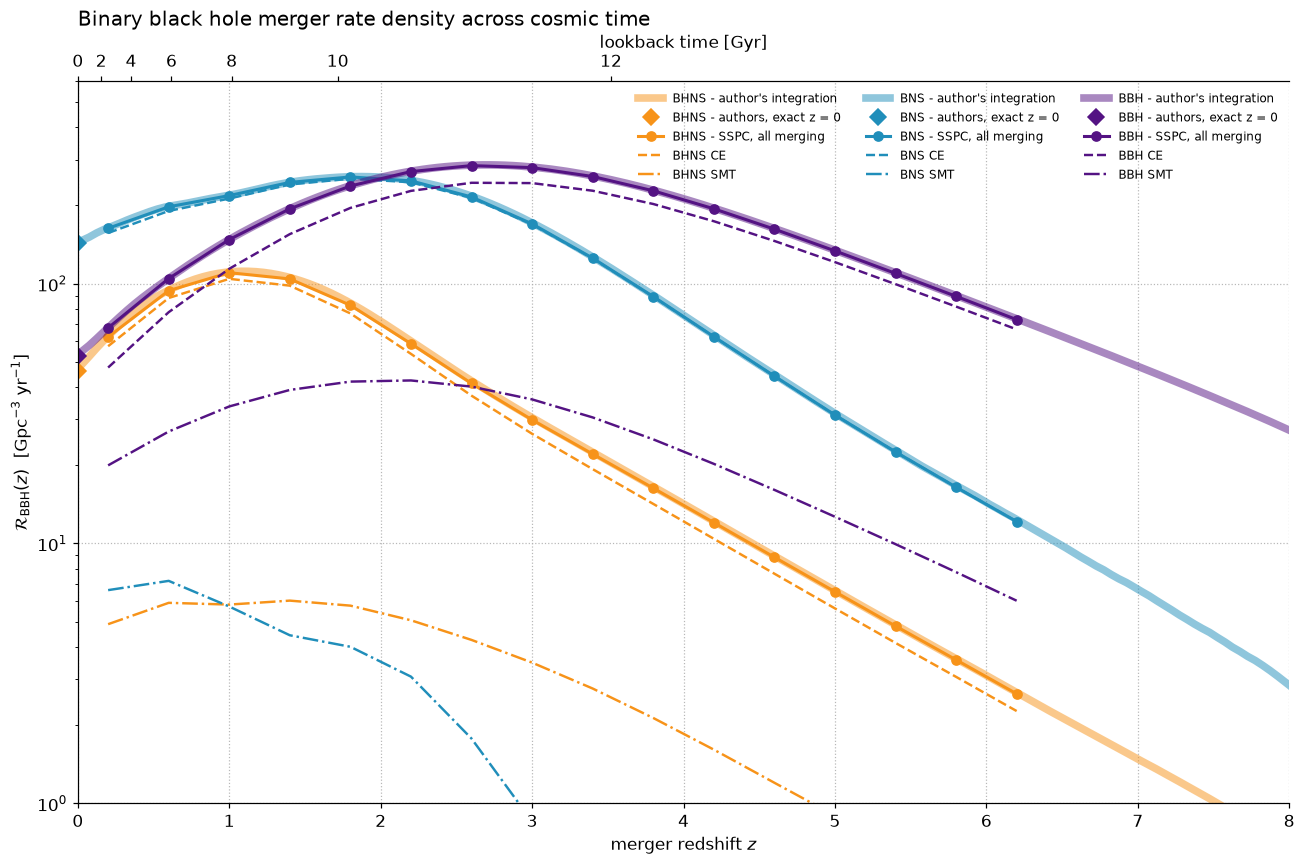

In [18]:
# channel split, as in Notebook 2 Part 5: no common envelope = stable mass transfer channel
C_BBH, C_BHNS, C_BNS =  "#541383", "#F79319", "#208EBA"

is_smt_bbh = (bbh.n_CE == 0).values
is_smt_bhns = (bhns.n_CE == 0).values
is_smt_bns = (bns.n_CE == 0).values
R_bbh_sspc_ce   = np.array([read_sspc_yield("bbh", z)[~is_smt_bbh].sum() for z in CONV_Z])
R_bbh_sspc_smt  = np.array([read_sspc_yield("bbh", z)[is_smt_bbh].sum() for z in CONV_Z])
R_bhns_sspc_ce  = np.array([read_sspc_yield("bhns", z)[~is_smt_bhns].sum() for z in CONV_Z])
R_bns_sspc_ce   = np.array([read_sspc_yield("bns", z)[~is_smt_bns].sum() for z in CONV_Z])
R_bhns_sspc_smt = np.array([read_sspc_yield("bhns", z)[is_smt_bhns].sum() for z in CONV_Z])
R_bns_sspc_smt  = np.array([read_sspc_yield("bns", z)[is_smt_bns].sum() for z in CONV_Z])

fig, ax = plt.subplots(figsize=(12, 8))
populations_new = [("BHNS", dco.is_BHNS, bhns, R_bhns_sspc, R_bhns_sspc_ce, R_bhns_sspc_smt, C_BHNS),
                   ("BNS",  dco.is_BNS,  bns,  R_bns_sspc, R_bns_sspc_ce, R_bns_sspc_smt, C_BNS), 
                   ("BBH",  dco.is_BBH,  bbh,  R_bbh_sspc, R_bbh_sspc_ce, R_bbh_sspc_smt, C_BBH),]
for name, mask, data, sspc, ce, smt, color in populations_new:
    ax.plot(z_authors, authors_rates[name], color=color, lw=5, alpha=0.5, label=f"{name} - author's integration")
    ax.plot([0], [R_authors_z0[name]], "D", color=color, ms=7, label=f"{name} - authors, exact z = 0")
    ax.plot(CONV_Z, sspc, "o-", color=color, lw=2, ms=6, label=f"{name} - SSPC, all merging")
    ax.plot(CONV_Z, ce,  "--", color=color,  lw=1.6, ms=4, label=f"{name} CE")
    ax.plot(CONV_Z, smt, "-.", color=color, lw=1.6, ms=4, label=f"{name} SMT")
# ax.plot(z_authors, authors_rates["BHNS"], color=C_BHNS, lw=5, alpha=0.5, label="BHNS - author's integration")
# ax.plot(z_authors, authors_rates["BNS"], color=C_BNS, lw=5, alpha=0.5, label="BNS - the authors' integration")
# ax.plot(z_authors, authors_rates["BBH"], color=C_BBH, lw=5, alpha=0.5, label="BBH - the authors' integration")
# ax.plot([0], [R_authors_z0["BHNS"]], "D", color=C_BHNS, ms=7, label="BHNS - authors, exact z = 0")
# ax.plot([0], [R_authors_z0["BNS"]], "D", color=C_BNS, ms=7, label="BNS - authors, exact z = 0")
# ax.plot([0], [R_authors_z0["BBH"]], "D", color=C_BBH, ms=7, label="BBH - authors, exact z = 0")
# ax.plot(CONV_Z, R_bhns_sspc, "o-", color=C_BHNS, lw=2, ms=6, label="BHNS - SSPC, all merging")
# ax.plot(CONV_Z, R_bns_sspc, "o-", color=C_BNS, lw=2, ms=6, label="BNS - SSPC, all merging")
# ax.plot(CONV_Z, R_bbh_sspc, "o-", color=C_BBH, lw=2, ms=6, label="BBH - SSPC, all merging")
# ax.plot(CONV_Z, R_bbh_sspc_ce,  "s--", color=C_BBH,  lw=1.6, ms=4, label="BBH CE")
# ax.plot(CONV_Z, R_bbh_sspc_smt, "o--", color=C_BBH, lw=1.6, ms=4, label="BBH SMT")
# ax.plot(CONV_Z, R_bhns_sspc_ce,  "s--", color=C_BHNS,  lw=1.6, ms=4, label="BHNS CE")
# ax.plot(CONV_Z, R_bhns_sspc_smt, "^--", color=C_BHNS, lw=1.6, ms=4, label="BHNS SMT")
# ax.plot(CONV_Z, R_bns_sspc_ce,  "*--", color=C_BNS,  lw=1.6, ms=4, label="BNS CE")
# ax.plot(CONV_Z, R_bns_sspc_smt, "^--", color=C_BNS, lw=1.6, ms=4, label="BNS SMT")

ax.set_yscale("log"); ax.set_ylim(1, 600); ax.set_xlim(0, 8)
ax.set_xlabel("merger redshift $z$")
ax.set_ylabel(r"$\mathcal{R}_{\rm BBH}(z)$  [Gpc$^{-3}$ yr$^{-1}$]")
ax.set_title("Binary black hole merger rate density across cosmic time", loc="left")
secax = ax.secondary_xaxis("top", functions=(lambda z: lookback_time_Myr(z) / 1e3,
                                             lambda t: redshift_at_lookback_time(t * 1e3)))
secax.set_xlabel("lookback time [Gyr]")
ax.legend(loc="upper right", fontsize=8, ncol=3)
plt.grid(True, alpha=0.9)
plt.tight_layout(); plt.show()


### **Discussion**

After filtering out the data for `BHNS` and `BNS`, I assigned each system to the metallicity bins and then calculated the metallicity-dependent $\eta$. Then added all of the extracted data into the SSPC file under  `input_data/bhns` and `input_data/bns` respectively. Then added the convolution instruction where I specifically delete the previous defined paramteres and rewrite it fresh since each run was increasing the size of the output file. I made a combined file for `BBH`, `BHNS` and `BNS` where with each run, the previous data will be deleted entirely and rewritten and convolution instructions will be added. After the cosmic integration, we extracted the rate of mergers, $\mathcal{R}(z = 0.2)$ and it does lies within the expected range, i.e. $8 - 140\; Gps^{-3}yr^{-1}$ for `BHNS` and $10-1700\; Gps^{-3}yr^{-1}$ for `BNS`.

The Author's Key also verified our result.

# Exercise 2

In [13]:
F_BIN = (0.7, 1.0, 0.5)

f_bin_ref = 0.7
mass_per_binary_ref = m_avg * (1.5 + (1 - f_bin_ref) / f_bin_ref)

f_sim = quad(lambda m: imf_pdf(m) * (1 - M2_MIN / m), M1_MIN, M1_MAX)[0]

M_REP_ref = mass_per_binary_drawn / f_sim
M_SIM = n_binaries_simulated * M_REP

for f in F_BIN:
    mass_per_binary_drawn = m_avg * (1.5 + (1 - f) / f)
    M_REP = mass_per_binary_drawn / f_sim
    factor = M_REP / M_REP_ref
    print(f"F_BIN = {f:.1f}   "
          f"M_rep = {M_REP:8.1f} Msun   "
          f"factor relative to F_BIN=0.7 = {factor:.4f}")

F_BIN = 0.7   M_rep =    101.7 Msun   factor relative to F_BIN=0.7 = 1.0000
F_BIN = 1.0   M_rep =     79.1 Msun   factor relative to F_BIN=0.7 = 0.7778
F_BIN = 0.5   M_rep =    131.9 Msun   factor relative to F_BIN=0.7 = 1.2963


#### **Discussion**

After changing the `F_BIN` from 0.7 to 1.0, there isn't any change in the fraction of binaries in a simulation. However, there is a significant change of represented mass, $M_{rep}$ per simulated binary and the total star-forming mass, $M_{sim}$ by the simulation as well.

For `F_BIN` = 0.7, we have: $$ M_{rep}: 101.7\; M_{\odot} \\ M_{sim}: 1.017e+09\; M_{\odot}$$

For `F_BIN` = 1.0, we have: $$ M_{rep}: 79.1\; M_{\odot} \\ M_{sim}: 7.911e+08\; M_{\odot} \\ Factor\;Change: 0.7778$$

For `F_BIN` = 0.5, we have: $$ M_{rep}: 131.9\; M_{\odot} \\ M_{sim}: 1.319e+09\; M_{\odot} \\ Factor\;Change: 1.2963$$

In [9]:
M1_MIN, M1_MAX = (5.0, 8.0), (150.0, 300.0)

M1_MIN_REF = 5.0
M1_MAX_REF = 150.0
M2_MIN = 0.1
F_BIN = 0.7

mass_per_binary_drawn = m_avg * (1.5 + (1 - F_BIN) / F_BIN)

f_sim_ref = quad(lambda m: imf_pdf(m) * (1 - M2_MIN / m), M1_MIN_REF, M1_MAX_REF)[0]

M_REP_ref = mass_per_binary_drawn / f_sim_ref
M_SIM_ref = n_binaries_simulated * M_REP_ref

print(f"Reference: M1 = {M1_MIN_REF:.1f}–{M1_MAX_REF:.1f} Msun")
print(f"f_sim = {f_sim_ref:.8f} "
      f"(1 in {1/f_sim_ref:.0f})")
print(f"M_rep = {M_REP_ref:.1f} Msun")
print(f"M_sim = {M_SIM_ref:.3e} Msun")

for m1_min, m1_max in zip(M1_MIN, M1_MAX):
    f_sim = quad(lambda m: imf_pdf(m) * (1 - M2_MIN / m), m1_min, m1_max)[0]
    M_REP = mass_per_binary_drawn / f_sim
    factor = M_REP / M_REP_ref
    M_SIM = n_binaries_simulated * M_REP
    print(f"\nM1 = {m1_min:.1f}–{m1_max:.1f} Msun")
    print(f"f_sim = {f_sim:.8f} "
          f"(1 in {1/f_sim:.0f})")
    print(f"M_rep = {M_REP:8.1f} Msun")
    print(f"M_sim = {M_SIM:.3e} Msun")
    print(f"factor relative to reference = {factor:.4f}")

Reference: M1 = 5.0–150.0 Msun
f_sim = 0.00736888 (1 in 136)
M_rep = 101.7 Msun
M_sim = 1.017e+09 Msun

M1 = 5.0–150.0 Msun
f_sim = 0.00736888 (1 in 136)
M_rep =    101.7 Msun
M_sim = 1.017e+09 Msun
factor relative to reference = 1.0000

M1 = 8.0–300.0 Msun
f_sim = 0.00400406 (1 in 250)
M_rep =    187.2 Msun
M_sim = 1.872e+09 Msun
factor relative to reference = 1.8403


#### **Discussion**

Changing the primary-mass range from the reference $5$–$150,M_\odot$ to $8$–$300,M_\odot$ changes the fraction of binaries represented by the simulation, $f_{\rm sim}$. Since $M_{\rm rep}=M_{\rm binary,drawn}/f_{\rm sim}$, a smaller $f_{\rm sim}$ leads to a larger represented mass per simulated binary. Thus, extending the upper mass limit to $300,M_\odot$ while raising the lower limit to $8,M_\odot$ changes the normalization of the simulation and consequently the total represented star-forming mass $M_{\rm sim}$. The factor $M_{\rm rep}/M_{\rm rep,ref}$ directly quantifies this change relative to the standard $5$–$150,M_\odot$ model.

# Exercise 3
BBH Primary Mass and Chirp Mass Distribution


In [19]:
Z_MASS = [0.2, 2.6]

M1_yield_distribution = {}
M1 = population_data["M1_raw"].values

for z in Z_MASS:
    yields = read_sspc_yield("bbh", z)
    assert len(M1) == len(yields)

    M1_yield_distribution[z] = {"M1": M1,
                                "yield": yields,}

chirp_mass = (bbh.m1.values * bbh.m2.values)**(3/5) / (bbh.m1.values + bbh.m2.values) ** (1/5)

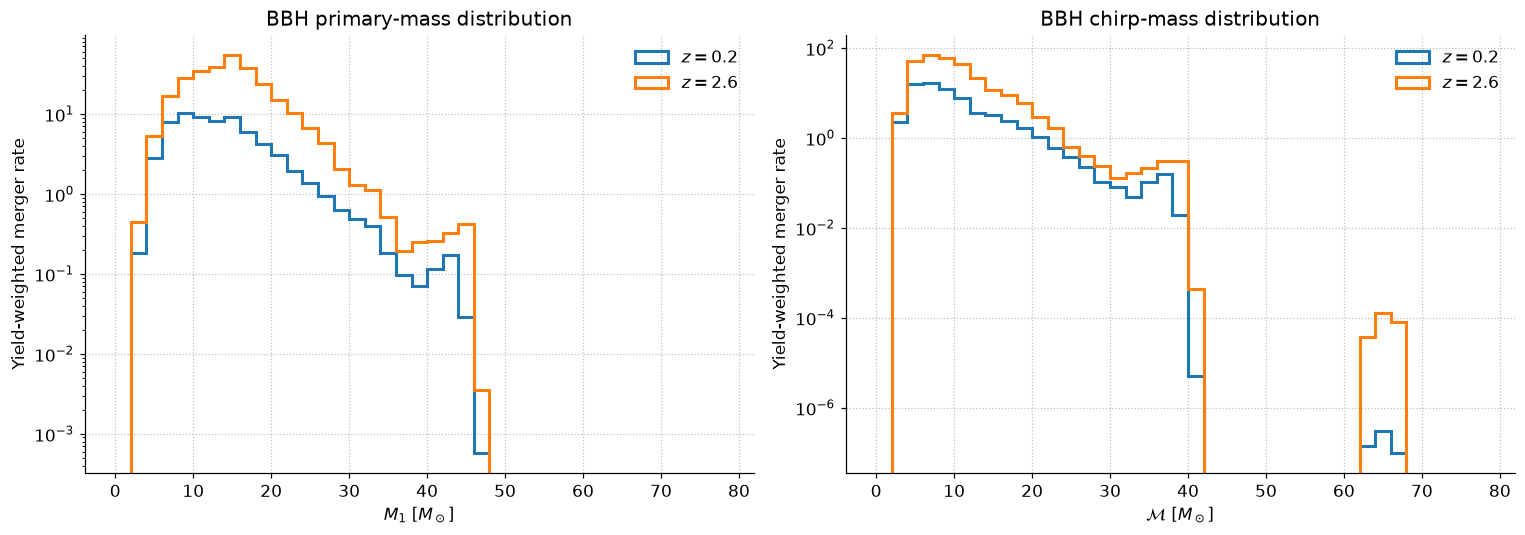

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plots = [
    (axes[0], bbh.m1.values, np.arange(0, 80, 2), r"$M_1\ [M_\odot]$", r"BBH primary-mass distribution"),
    (axes[1], chirp_mass, np.arange(0, 80, 2), r"$\mathcal{M}\ [M_\odot]$", r"BBH chirp-mass distribution")]

for ax, quantity, bins, xlabel, title in plots:
    for z in Z_MASS:
        ax.hist(quantity, bins=bins, weights=M1_yield_distribution[z]["yield"], histtype="step", linewidth=2, label=f"$z={z}$")

    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Yield-weighted merger rate")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.8)

plt.tight_layout()
plt.show()


# Exercise 4
Birth redshift of BBHs merging with SSFC yields as the weights


Original eta: 7.6% of mergers born at z_birth > 1
BBH: 31.7% of mergers born at z_birth > 1
CE: 20.2% of mergers born at z_birth > 1
SMT: 58.9% of mergers born at z_birth > 1


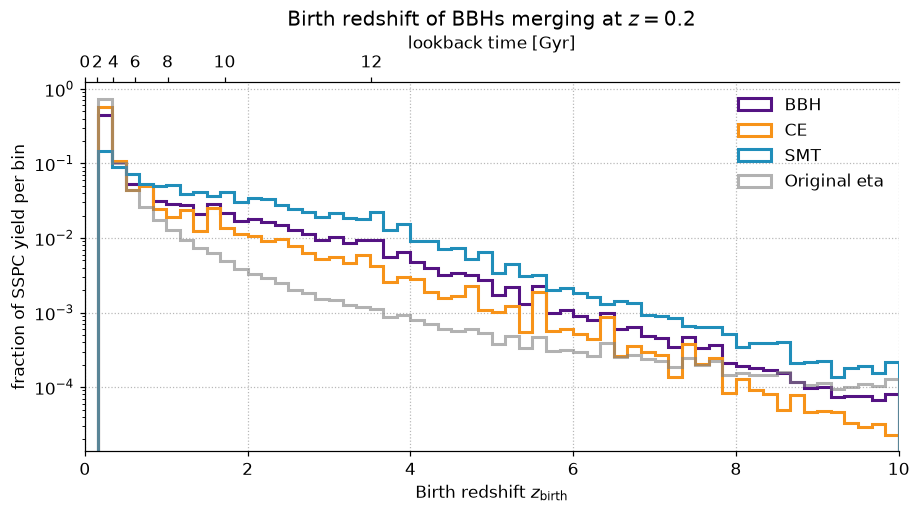

In [21]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

C_BBH, C_CE, C_SMT = "#541383", "#F79319", "#208EBA"

z_merge = 0.2
bins = np.linspace(0, 10, 61)

# Birth redshift
t_birth = lookback_time_Myr(z_merge) + bbh.t_delay_Myr.values
z_birth = redshift_at_lookback_time(t_birth)
born = t_birth < T_LB_FIRST_STARS_MYR

# Original weight as eta
eta_ok = bbh.eta.values[born]
print(f"Original eta: {100*eta_ok[z_birth[born] > 1].sum()/eta_ok.sum():.1f}% of mergers born at z_birth > 1")

# SSPC yield
yields = read_sspc_yield("bbh", z_merge)

channels = [("BBH", np.ones(len(bbh), dtype=bool), C_BBH), ("CE", bbh.n_CE.values != 0, C_CE), ("SMT", bbh.n_CE.values == 0, C_SMT)]

for name, channel_mask, color in channels:
    valid = (born & np.isfinite(z_birth) & (z_birth >= 0.2) & (z_birth <= 10) & channel_mask & (yields > 0))
    z = z_birth[valid]
    y = yields[valid]

    ax.hist(z, bins=bins, weights = y/y.sum(), histtype="step", lw=2, color=color, label=name)

    fraction = y[z>1].sum() / y.sum()

    print(f"{name}: {100* fraction:.1f}% of mergers born at z_birth > 1")

ax.hist(z_birth[born], bins=bins, weights=eta_ok / eta_ok.sum(), histtype="step", lw=2, color="grey", ls='-', alpha=0.6, label='Original eta')
ax.set_yscale("log")
ax.set_xlim(0, 10)
ax.set_xlabel(r"Birth redshift $z_{\rm birth}$")
ax.set_ylabel(r"fraction of SSPC yield per bin")

secax = ax.secondary_xaxis("top",functions=(lambda z: lookback_time_Myr(z) / 1e3,
                                            lambda t: redshift_at_lookback_time(t * 1e3),))
secax.set_xlabel("lookback time [Gyr]")

ax.set_title("Birth redshift of BBHs merging at $z = 0.2$")
ax.legend()
ax.grid(True, alpha=0.9)

plt.tight_layout()
plt.show()


#### **Discussion**

For BBHs merging at $z=0.2$, the $\eta$-weighted calculation from §2.4 gave a fraction of about 7.6% born at $z_{\rm birth}>1$, before accounting for the cosmic star-formation history. After replacing $\eta$ with the SSPC yields, this fraction changes because the yields include the effects of the star-formation rate and metallicity distribution at the binary's birth redshift. Since star formation was much higher around $z\sim2$, the high-redshift-born systems receive greater weight, increasing their contribution to the present-day merger population. 

Splitting the population into common-envelope (CE) and stable mass-transfer (SMT) channels shows that the two channels have different birth-redshift distributions. This reflects their different delay-time and evolutionary histories, while the SSPC weighting additionally accounts for the cosmic conditions under which their progenitor binaries formed. The exercise therefore shows that today's merger population is not simply a reflection of the intrinsic binary delay-time distribution; it is also shaped by the history of star formation and metallicity across cosmic time.

# Exercise 5
Swapping the Universe with Madau & Dickinson (2014) figucial parameters

#### SFR- MD14

In [30]:
# sfr_density
def sfr_density(z, a=0.015, b=2.7, c=2.9, d=5.6):
    '''Madau & Dickinson (2014) functional form
    Returns Msun / yr / Mpc^3 (comoving).'''
    return a * (1 + z) ** b / (1 + ((1 + z) / c) ** d)


# --- redshift grid for the star formation history ------------------------------------------
Z_SFR_EDGES = np.linspace(0, 10, 201)
z_sfr_centres = 0.5 * (Z_SFR_EDGES[1:] + Z_SFR_EDGES[:-1])
psi_grid = sfr_density(z_sfr_centres) * 1e9 * u.Msun / u.yr / u.Gpc**3          # Mpc^-3 -> Gpc^-3

# --- metallicity grid: the SAME bins as eta (section 1.5), now in linear Z ------------------
Z_EDGES_LIN = 10 ** LOG_Z_EDGES

# fraction of star formation in each metallicity bin, integrated on a fine sub-grid (40 per bin)
N_SUB = 40
lnZ_fine = np.linspace(np.log(Z_EDGES_LIN[0]), np.log(Z_EDGES_LIN[-1]), N_Z_BINS * N_SUB + 1)
P_fine = dP_dlnZ(0.5 * (lnZ_fine[1:] + lnZ_fine[:-1]), z_sfr_centres) * np.diff(lnZ_fine)   # (200, 50*40)
dP_per_bin = P_fine.reshape(len(z_sfr_centres), N_Z_BINS, N_SUB).sum(axis=2)                  # (200, 50)
dPdZ_grid = dP_per_bin / np.diff(Z_EDGES_LIN)[None, :]                                        # what SSPC wants

sfr_dict = {
    "redshift_bin_edges":             Z_SFR_EDGES,
    "starformation_rate_array":       psi_grid,
    "metallicity_bin_edges":          Z_EDGES_LIN,
    "metallicity_distribution_array": dPdZ_grid,
}

bbh = dco[dco.is_BBH & (dco.merges == 1)].copy()

print(f"binaries simulated           : {n_binaries_simulated:,}")
print(f"double compact objects       : {len(dco):,}")
print(f"merging BBH (rows)           : {len(bbh):,}")
print(f"merging BBH (sum w)          : {bbh.w.sum():,.0f}")

# Assigning each system to its respective metallicity bin
mass_per_bin = mass_formed_per_bin(LOG_Z_EDGES)
for name, population in [("bbh", bbh)]:
    population["z_bin"] = np.clip(np.digitize(np.log10(population.Z), LOG_Z_EDGES) - 1, 0, N_Z_BINS - 1)
    population["eta"] = population.w / mass_per_bin[population.z_bin.values]


binaries simulated           : 10,000,000
double compact objects       : 2,523,122
merging BBH (rows)           : 1,640,550
merging BBH (sum w)          : 14,911


In [31]:
# Fresh SSPC file + input tables + convolution

SSPC_DIR = "data/sspc"
os.makedirs(os.path.join(SSPC_DIR, "tmp"), exist_ok=True)

SSPC_FILE_MD14 = os.path.join(SSPC_DIR, "vanSon22_BBH_MD14.h5")

## Start from a completely fresh HDF5 file
if os.path.exists(SSPC_FILE_MD14):
    os.remove(SSPC_FILE_MD14)

generate_boilerplate_outputfile(SSPC_FILE_MD14)


# Write all three populations into the fresh SSPC file
for name, population in [("bbh", bbh)]:

    sspc_input = pd.DataFrame({
        "delay_time": population.t_delay_Myr.values,
        "metallicity": population.Z.values,
        "eta": population.eta.values,
    })

    sspc_input.to_hdf(SSPC_FILE_MD14, key=f"input_data/{name}")
    print(f"{len(sspc_input):,} rows written to input_data/{name}")


# SSPC convolution configuration
CONV_Z_EDGES = np.arange(0.0, 6.41, 0.4)

config = copy.copy(default_convolution_config)

config["logger"].setLevel(logging.ERROR)
config["output_filename"] = SSPC_FILE_MD14
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator_MD14.p")
config["time_type"] = "redshift"
config["cosmology"] = cosmo
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict

config["convolution_instructions"] = [

    ## BBH
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bbh",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },
]

# Run convolution

t0 = time.time()
convolve(config=config)

print(
    f"\nDone in {time.time() - t0:.0f} s; "
    f"output file is now "
    f"{os.path.getsize(SSPC_FILE_MD14)/1e6:.0f} MB"
)

# Extract the yield
with h5py.File(SSPC_FILE_MD14, "r") as f:
    bbh_yield_MD14  = f["output_data/bbh/rates/convolution_results/0.2/yield"][:]

R_bbh_MD14  = bbh_yield_MD14.sum()

def read_sspc_yield_new(sspc_file, population_name, z_centre):
    with h5py.File(sspc_file, "r") as f:
        key = (
            f"output_data/{population_name}/rates/"
            f"convolution_results/{np.round(z_centre, 4)}/yield"
        )
        return f[key][()]


1,640,550 rows written to input_data/bbh

Done in 9 s; output file is now 264 MB


#### MUZ015

In [34]:
def sfr_density(z, a=0.02, b=2.6, c=2.9, d=5.6):
    return a * (1 + z) ** b / (1 + ((1 + z) / c) ** d)

# dP_dlnZ
P_fine = dP_dlnZ(0.5 * (lnZ_fine[1:] + lnZ_fine[:-1]), z_sfr_centres, 
                 muz=-0.15) * np.diff(lnZ_fine)
dP_per_bin = P_fine.reshape(len(z_sfr_centres), N_Z_BINS, N_SUB).sum(axis=2)
dPdZ_grid = dP_per_bin / np.diff(Z_EDGES_LIN)[None, :] 

sfr_dict = {
    "redshift_bin_edges":             Z_SFR_EDGES,
    "starformation_rate_array":       psi_grid,
    "metallicity_bin_edges":          Z_EDGES_LIN,
    "metallicity_distribution_array": dPdZ_grid,
}


In [36]:
SSPC_FILE_MUZ015 = os.path.join(SSPC_DIR, "vanSon22_BBH_muz015.h5")

if os.path.exists(SSPC_FILE_MUZ015):
    os.remove(SSPC_FILE_MUZ015)

generate_boilerplate_outputfile(SSPC_FILE_MUZ015)

sspc_input = pd.DataFrame({
    "delay_time": bbh.t_delay_Myr.values,
    "metallicity": bbh.Z.values,
    "eta": bbh.eta.values,
})

sspc_input.to_hdf(SSPC_FILE_MUZ015, key="input_data/bbh")
print(f"{len(sspc_input):,} rows written to input_data/{name}")

config = copy.copy(default_convolution_config)

config["logger"].setLevel(logging.ERROR)
config["output_filename"] = SSPC_FILE_MUZ015
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator_muz015.p")
config["time_type"] = "redshift"
config["cosmology"] = cosmo
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict

config["convolution_instructions"] = [
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bbh",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },
]

# Run Convolution

t0 = time.time()
convolve(config=config)

print(
    f"\nDone in {time.time() - t0:.0f} s; "
    f"output file is now "
    f"{os.path.getsize(SSPC_FILE_MUZ015)/1e6:.0f} MB"
)


1,640,550 rows written to input_data/bbh

Done in 10 s; output file is now 264 MB


#### $\alpha = 0$

In [ ]:
def sfr_density(z, a=0.02, b=2.6, c=2.9, d=5.6):
    return a * (1 + z) ** b / (1 + ((1 + z) / c) ** d)

# dP_dlnZ
P_fine = dP_dlnZ(0.5 * (lnZ_fine[1:] + lnZ_fine[:-1]), z_sfr_centres, 
                 alpha=0) * np.diff(lnZ_fine)
dP_per_bin = P_fine.reshape(len(z_sfr_centres), N_Z_BINS, N_SUB).sum(axis=2)
dPdZ_grid = dP_per_bin / np.diff(Z_EDGES_LIN)[None, :] 

sfr_dict = {
    "redshift_bin_edges":             Z_SFR_EDGES,
    "starformation_rate_array":       psi_grid,
    "metallicity_bin_edges":          Z_EDGES_LIN,
    "metallicity_distribution_array": dPdZ_grid,
}

In [101]:
SSPC_FILE_ALPHA0 = os.path.join(SSPC_DIR, "vanSon22_BBH_alpha0.h5")

if os.path.exists(SSPC_FILE_ALPHA0):
    os.remove(SSPC_FILE_ALPHA0)

generate_boilerplate_outputfile(SSPC_FILE_ALPHA0)

sspc_input = pd.DataFrame({
    "delay_time": bbh.t_delay_Myr.values,
    "metallicity": bbh.Z.values,
    "eta": bbh.eta.values,
})

sspc_input.to_hdf(SSPC_FILE_ALPHA0, key="input_data/bbh")
print(f"{len(sspc_input):,} rows written to input_data/{name}")

config = copy.copy(default_convolution_config)

config["logger"].setLevel(logging.ERROR)
config["output_filename"] = SSPC_FILE_ALPHA0
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator_alpha0.p")
config["time_type"] = "redshift"
config["cosmology"] = cosmo
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict

config["convolution_instructions"] = [
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bbh",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },
]

# Run Convolution

t0 = time.time()
convolve(config=config)

print(
    f"\nDone in {time.time() - t0:.0f} s; "
    f"output file is now "
    f"{os.path.getsize(SSPC_FILE_ALPHA0)/1e6:.0f} MB"
)


1,640,550 rows written to input_data/bbh

Done in 15 s; output file is now 264 MB


#### Combined Result and Comparison

In [84]:
# Extract the yield
R_bbh_sspc_ALPHA0 = np.array([read_sspc_yield_new(SSPC_FILE_ALPHA0, "bbh", z).sum() for z in CONV_Z])
R_bbh_sspc_MUZ015 = np.array([read_sspc_yield_new(SSPC_FILE_MUZ015, "bbh", z).sum() for z in CONV_Z])
R_bbh_sspc_MD14 = np.array([read_sspc_yield_new(SSPC_FILE_MD14, "bbh", z).sum() for z in CONV_Z])
R_bbh_sspc = np.array([read_sspc_yield_new(SSPC_FILE_ORIGINAL, "bbh", z).sum() for z in CONV_Z])
i_original = np.argmax(R_bbh_sspc)
i_MD14 = np.argmax(R_bbh_sspc_MD14)
i_MUZ015 = np.argmax(R_bbh_sspc_MUZ015)
i_ALPHA0 = np.argmax(R_bbh_sspc_ALPHA0)

print(f"\n--------------R (z=0.2)-----------------")
print(f"BBH merger rate at z=0.2                             : {R_bbh_sspc[0]:.2f} Gpc^-3 yr^-1")
print(f"BBH_MD14 merger rate at z=0.2 (Madau-Dickinson Ψ(z)) : {R_bbh_sspc_MD14[0]:.2f} Gpc^-3 yr^-1; fraction: {(R_bbh_sspc_MD14[0]/R_bbh_sspc[0] - 1):+.1%}")
print(f"BBH_MUZ015 merger rate at z=0.2 (μ_z = -0.15)        : {R_bbh_sspc_MUZ015[0]:.2f} Gpc^-3 yr^-1; fraction: {(R_bbh_sspc_MUZ015[0]/R_bbh_sspc[0] - 1):+.1%}")
print(f"BBH_ALPHA0 merger rate at z=0.2 (α = 0)              : {R_bbh_sspc_ALPHA0[0]:.2f} Gpc^-3 yr^-1; fraction: {(R_bbh_sspc_ALPHA0[0]/R_bbh_sspc[0] - 1):+.1%}")
print()
print(f"\n--------------Peak R-----------------")
print(f"BBH merger rate at z = {CONV_Z[i_original]:.1f}                  : {R_bbh_sspc[i_original]:.2f} Gpc^-3 yr^-1")
print(f"Madau-Dickinson Ψ(z) merger rate at z = {CONV_Z[i_MD14]:.1f} : {R_bbh_sspc_MD14[i_MD14]:.2f} Gpc^-3 yr^-1")
print(f"μ_z = -0.15 merger rate at z = {CONV_Z[i_MUZ015]:.1f}          : {R_bbh_sspc_MUZ015[i_MUZ015]:.2f} Gpc^-3 yr^-1")
print(f"α = 0 merger rate at z = {CONV_Z[i_ALPHA0]:.1f}                : {R_bbh_sspc_ALPHA0[i_ALPHA0]:.2f} Gpc^-3 yr^-1")



--------------R (z=0.2)-----------------
BBH merger rate at z=0.2                             : 67.52 Gpc^-3 yr^-1
BBH_MD14 merger rate at z=0.2 (Madau-Dickinson Ψ(z)) : 76.60 Gpc^-3 yr^-1; fraction: +13.4%
BBH_MUZ015 merger rate at z=0.2 (μ_z = -0.15)        : 96.54 Gpc^-3 yr^-1; fraction: +43.0%
BBH_ALPHA0 merger rate at z=0.2 (α = 0)              : 152.51 Gpc^-3 yr^-1; fraction: +125.9%


--------------Peak R-----------------
BBH merger rate at z = 2.6                  : 284.50 Gpc^-3 yr^-1
Madau-Dickinson Ψ(z) merger rate at z = 1.8 : 302.14 Gpc^-3 yr^-1
μ_z = -0.15 merger rate at z = 2.2          : 495.87 Gpc^-3 yr^-1
α = 0 merger rate at z = 1.8                : 641.97 Gpc^-3 yr^-1


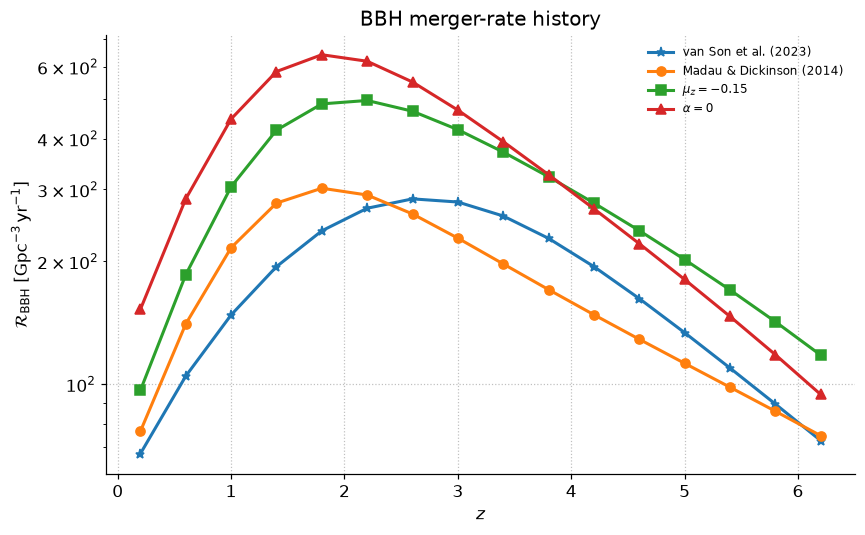

In [88]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(CONV_Z, R_bbh_sspc, lw=2, marker="*", label="van Son et al. (2023)")
ax.plot(CONV_Z, R_bbh_sspc_MD14, lw=2, marker="o", label="Madau & Dickinson (2014)")
ax.plot(CONV_Z, R_bbh_sspc_MUZ015, lw=2, marker="s", label=r"$\mu_z = -0.15$")
ax.plot(CONV_Z, R_bbh_sspc_ALPHA0, lw=2, marker="^", label=r"$\alpha = 0$")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\mathcal{R}_{\rm BBH}\ [\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$")
ax.set_yscale('log')
ax.set_title("BBH merger-rate history")
ax.legend(fontsize=8)
ax.grid(alpha=0.8)

plt.tight_layout()
plt.show()

#### **Discussion**
- By changing $\psi(z)$ from van Son 2022 to Madau-Dickinson parameters, the rate raises by $13.4\%$
- Changing $\mu_z to -0.015$ raises the rate by $43.0\%$
- Setting $\alpha = 0$ raises the rate by $125.9\%$, largest of the fractional change.
  
It matches with the table in §4.4.

# Exercise 6

In [103]:
N_Z_BINS = 50
LOG_Z_EDGES = np.linspace(LOG_Z_MIN, LOG_Z_MAX, N_Z_BINS + 1)
mass_per_bin = mass_formed_per_bin(LOG_Z_EDGES)


bbh["z_bin"] = np.clip(np.digitize(np.log10(bbh.Z), LOG_Z_EDGES) - 1, 0, N_Z_BINS - 1)
bbh["eta"]   = bbh.w / mass_per_bin[bbh.z_bin.values]
bbh["eta_wrong"] = bbh.w / M_SIM

SSPC_FILE_WRONG = os.path.join(SSPC_DIR,"vanSon22_BBH_wrong_MSIM.h5")

if os.path.exists(SSPC_FILE_WRONG):
    os.remove(SSPC_FILE_WRONG)

generate_boilerplate_outputfile(SSPC_FILE_WRONG)

sspc_input_wrong = pd.DataFrame({
    "delay_time": bbh.t_delay_Myr.values,
    "metallicity": bbh.Z.values,
    "eta_wrong": bbh.eta_wrong.values,
})

sspc_input_wrong.to_hdf(SSPC_FILE_WRONG, key='input_data/bbh')

config = copy.copy(default_convolution_config)

config["logger"].setLevel(logging.ERROR)
config["output_filename"] = SSPC_FILE_WRONG
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator_wrong_MSIM.p")
config["time_type"] = "redshift"
config["cosmology"] = cosmo
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict

config["convolution_instructions"] = [
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bbh",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta_wrong",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },
]

# Run Convolution

t0 = time.time()
convolve(config=config)

print(
    f"\nDone in {time.time() - t0:.0f} s; "
    f"output file is now "
    f"{os.path.getsize(SSPC_FILE_WRONG)/1e6:.0f} MB"
)




Done in 11 s; output file is now 264 MB


In [ ]:
N_Z_BINS_200 = 200
LOG_Z_EDGES = np.linspace(LOG_Z_MIN, LOG_Z_MAX, N_Z_BINS_200 + 1)
mass_per_bin = mass_formed_per_bin(LOG_Z_EDGES)

bbh["z_bin"] = np.clip(np.digitize(np.log10(bbh.Z), LOG_Z_EDGES) - 1, 0, N_Z_BINS_200 - 1)
bbh["eta"]   = bbh.w / mass_per_bin[bbh.z_bin.values]
bbh["eta_wrong_200"] = bbh.w / M_SIM

Z_SFR_EDGES = np.linspace(0, 10, 201)
z_sfr_centres = 0.5 * (Z_SFR_EDGES[1:] + Z_SFR_EDGES[:-1])
psi_grid = sfr_density(z_sfr_centres) * 1e9 * u.Msun / u.yr / u.Gpc**3

Z_EDGES_LIN = 10 ** LOG_Z_EDGES

N_SUB = 40
lnZ_fine = np.linspace(np.log(Z_EDGES_LIN[0]), np.log(Z_EDGES_LIN[-1]), N_Z_BINS_200 * N_SUB + 1)
P_fine = dP_dlnZ(0.5 * (lnZ_fine[1:] + lnZ_fine[:-1]), z_sfr_centres) * np.diff(lnZ_fine)   # (200, 50*40)
dP_per_bin = P_fine.reshape(len(z_sfr_centres), N_Z_BINS_200, N_SUB).sum(axis=2)                  # (200, 200)
dPdZ_grid = dP_per_bin / np.diff(Z_EDGES_LIN)[None, :]                                        # what SSPC wants

sfr_dict_200 = {
    "redshift_bin_edges":             Z_SFR_EDGES,
    "starformation_rate_array":       psi_grid,
    "metallicity_bin_edges":          Z_EDGES_LIN,
    "metallicity_distribution_array": dPdZ_grid,
}


SSPC_FILE_WRONG200 = os.path.join(SSPC_DIR,"vanSon22_BBH_wrong_MSIM200.h5")

if os.path.exists(SSPC_FILE_WRONG200):
    os.remove(SSPC_FILE_WRONG200)

generate_boilerplate_outputfile(SSPC_FILE_WRONG200)

sspc_input_wrong_200 = pd.DataFrame({
    "delay_time": bbh.t_delay_Myr.values,
    "metallicity": bbh.Z.values,
    "eta_wrong_200": bbh.eta_wrong_200.values,
})

sspc_input_wrong_200.to_hdf(SSPC_FILE_WRONG200, key='input_data/bbh')

config = copy.copy(default_convolution_config)

config["logger"].setLevel(logging.ERROR)
config["output_filename"] = SSPC_FILE_WRONG200
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator_wrong_MSIM200.p")
config["time_type"] = "redshift"
config["cosmology"] = cosmo
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict_200

config["convolution_instructions"] = [
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bbh",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta_wrong_200",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },
]

# Run Convolution

t0 = time.time()
convolve(config=config)

print(
    f"\nDone in {time.time() - t0:.0f} s; "
    f"output file is now "
    f"{os.path.getsize(SSPC_FILE_WRONG200)/1e6:.0f} MB"
)



Done in 13 s; output file is now 269 MB


In [115]:
N_Z_BINS_200 = 200
LOG_Z_EDGES = np.linspace(LOG_Z_MIN, LOG_Z_MAX, N_Z_BINS_200 + 1)
mass_per_bin = mass_formed_per_bin(LOG_Z_EDGES)

bbh["z_bin"] = np.clip(np.digitize(np.log10(bbh.Z), LOG_Z_EDGES) - 1, 0, N_Z_BINS_200 - 1)
bbh["eta"]   = bbh.w / mass_per_bin[bbh.z_bin.values]
bbh["eta_correct_200"] = bbh.w / mass_per_bin[bbh.z_bin.values]


SSPC_FILE_CORRECT200 = os.path.join(SSPC_DIR,"vanSon22_BBH_correct_MSIM200.h5")

if os.path.exists(SSPC_FILE_CORRECT200):
    os.remove(SSPC_FILE_CORRECT200)

generate_boilerplate_outputfile(SSPC_FILE_CORRECT200)

sspc_input_correct_200 = pd.DataFrame({
    "delay_time": bbh.t_delay_Myr.values,
    "metallicity": bbh.Z.values,
    "eta_correct_200": bbh.eta_correct_200.values,
})

sspc_input_correct_200.to_hdf(SSPC_FILE_CORRECT200, key='input_data/bbh')

config = copy.copy(default_convolution_config)

config["logger"].setLevel(logging.ERROR)
config["output_filename"] = SSPC_FILE_CORRECT200
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator_correct_MSIM200.p")
config["time_type"] = "redshift"
config["cosmology"] = cosmo
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict_200

config["convolution_instructions"] = [
    {
        **default_convolution_instruction,
        "convolution_type": "integrate",
        "input_data_name": "bbh",
        "output_data_name": "rates",
        "data_column_dict": {
            "normalized_yield": "eta_correct_200",
            "delay_time": {
                "column_name": "delay_time",
                "unit": u.Myr
            },
            "metallicity": "metallicity",
        },
    },
]

# Run Convolution

t0 = time.time()
convolve(config=config)

print(
    f"\nDone in {time.time() - t0:.0f} s; "
    f"output file is now "
    f"{os.path.getsize(SSPC_FILE_CORRECT200)/1e6:.0f} MB"
)



Done in 12 s; output file is now 269 MB


In [116]:
n_correct_50 = read_sspc_yield_new(SSPC_FILE_ORIGINAL, "bbh", 0.2)
n_wrong_50 = read_sspc_yield_new(SSPC_FILE_WRONG, "bbh", 0.2)

R_correct_50 = n_correct_50.sum()
R_wrong_50   = n_wrong_50.sum()

n_correct_200 = read_sspc_yield_new(SSPC_FILE_CORRECT200, "bbh", 0.2)
n_wrong_200   = read_sspc_yield_new(SSPC_FILE_WRONG200, "bbh", 0.2)

R_correct_200 = n_correct_200.sum()
R_wrong_200   = n_wrong_200.sum()

print("---------- N_Z = 50 ------------")
print(f"Correct R(z=0.2) = {R_correct_50:.4f} Gpc^-3 yr^-1")
print(f"Wrong   R(z=0.2) = {R_wrong_50:.4f} Gpc^-3 yr^-1")
print(f"Correct / Wrong  = {R_correct_50/R_wrong_50:.2f}")
print(f"Wrong / Correct  = {R_wrong_50/R_correct_50:.4f}")
print("\n---------- N_Z = 200 ------------")
print(f"Correct R(z=0.2) = {R_correct_200:.4f} Gpc^-3 yr^-1")
print(f"Wrong   R(z=0.2) = {R_wrong_200:.4f} Gpc^-3 yr^-1")
print(f"Correct / Wrong  = {R_correct_200/R_wrong_200:.2f}")
print(f"Wrong / Correct  = {R_wrong_200/R_correct_200:.4f}")

---------- N_Z = 50 ------------
Correct R(z=0.2) = 67.5219 Gpc^-3 yr^-1
Wrong   R(z=0.2) = 1.3504 Gpc^-3 yr^-1
Correct / Wrong  = 50.00
Wrong / Correct  = 0.0200

---------- N_Z = 200 ------------
Correct R(z=0.2) = 67.4407 Gpc^-3 yr^-1
Wrong   R(z=0.2) = 0.3372 Gpc^-3 yr^-1
Correct / Wrong  = 200.00
Wrong / Correct  = 0.0050


#### **Discussion**
The correct rate will be **$67.5\, Gpc^{-3}\, yr^{-1}$** at both $N_Z = 50\;and\;200$. It will not move as expected. However, the wrong rate is $50$ times less than the correct rate for $N_Z = 50$ and $200$ times less for $N_Z = 200$. So the number of bins increased by 4 times while the actual rate drops down by 4 times.

**A Collaborator Take-away:** SSPC's normalized yield must be the number of mergers per unit stellar mass represented by the metallicity bin, not per unit total simulated mass. Since the simulation is distributed across metallicity bins, each bin represents only a fraction of the total simulated mass. Dividing by $M_{\rm SIM}$ therefore underestimates the per-bin efficiency by a factor that depends directly on the arbitrary number of metallicity bins. Consequently, the resulting cosmic merger rate changes when the metallicity grid is refined from 50 to 200 bins, which is unphysical. Dividing by the mass represented by each bin, $M_j=M_{\rm SIM}\Delta\log Z_j/\Delta\log Z_{\rm tot}$, removes this dependence, so the correct cosmic rate remains stable under changes in bin resolution.